# 03 — SHAP Explanations

For each window pair (A, B), the notebook computes per-replica SHAP attributions on
the flagged set F_{A,B}. The explainer used depends on `MODEL_TYPE`:

| MODEL_TYPE  | Explainer               | Properties                                                |
|-------------|-------------------------|-----------------------------------------------------------|
| `xgboost`   | `shap.TreeExplainer`    | deterministic for a fixed fitted tree model; runs on CPU  |
| `mlp_plr`   | `shap.GradientExplainer`| stochastic, approximate; requires GPU                     |

**Output layout** (under `data/shap/{MODEL_TYPE}/pair_{pid:02d}/`):

- `shap_A.npy`, `shap_B.npy` — shape `(R, n_explained, p)`, float32.
  For XGBoost, `n_explained = |F|`; for MLP-PLR, `n_explained` may be a capped SHAP subsample.
- `mlp_shap_subsample_idx.npy` *(MLP-PLR only)* — positions within `flagged_idx` used for MLP-SHAP.
- `run_params.json` — explainer configuration fingerprint for stale-output detection.
- `expected_values_A.npy`, `expected_values_B.npy` — shape `(R,)`, float32.
- **Stochasticity diagnostic outputs** (§15) — produced by the diagnostic cell below; consumed by notebook 04:
  - `shap_stoch_A.npy`, `shap_stoch_B.npy` — shape `(Q, n_explained, p)`, float32, raw multi-run SHAP attributions on the central replica per side. `Q = N_STOCH_RUNS` for stochastic explainers; `Q = 1` for deterministic TreeSHAP.
  - `stochasticity.json` — run descriptor only, `schema_version = 'stoch_raw_runs_v1'`: `{schema_version, n_runs, run_seeds, replica_selection, replica_A, replica_B, n_explained, n_features, explained_local_idx_sha1, is_deterministic_runs}`. No aggregated numbers; all cosine / RBO distances are computed in notebook 04.
- `global_importance_pair00_A.png` — top-20 global importance plot for pair 0.

**Coordinate system note (MLP-PLR):** MLP-PLR models are trained on *scaled* features
(each replica has its own `StandardScaler`). SHAP attributions are computed in the
scaled-feature space and saved as such. Feature positions still match the 119-column
ordering in `feature_names.json` — only magnitudes differ. 

Cosine distance and RBO-on-|attribution| rankings (applied by notebook 04) reduce the
emphasis on raw magnitude differences, but they do not make the comparison independent
of per-replica scaling or background choices. The MLP-PLR SHAP results should
therefore be interpreted as end-to-end explanation behaviour for the fitted
replica pipelines.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import shap
from pathlib import Path
import hashlib

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Model type — must match the MODEL_TYPE used in notebook 02 / 02b ──
MODEL_TYPE = 'xgboost'   # 'xgboost' | 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
SHAP_DIR  = WORKSPACE / 'data' / 'shap'  / MODEL_TYPE
SHAP_DIR.mkdir(parents=True, exist_ok=True)

print(f'SHAP version: {shap.__version__}')
print(f'MODEL_TYPE : {MODEL_TYPE}')


SHAP version: 0.51.0
MODEL_TYPE : xgboost


In [4]:
# Load data and window config
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')

with open(PROC_DIR / 'feature_names.json') as f:
    feature_names_json = json.load(f)

feature_names = feature_names_json['all']

assert list(X_df.columns) == feature_names, (
    "X.parquet column order does not match feature_names['all']. "
    "This would misalign saved SHAP attributions with feature names."
)

X = X_df.values.astype(np.float32)

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R     = config['parameters']['R']
pairs = config['pairs']

print(f'X: {X.shape}, features: {len(feature_names)}')
print(f'R={R}, {len(pairs)} pairs')

X: (160057, 119), features: 119
R=8, 2 pairs


In [5]:
# ═════════════════════════════════════════════════════════════════════════════
# MLP-PLR setup — only runs when MODEL_TYPE == 'mlp_plr'.
# The MLPPLR / PLREmbedding classes below must be byte-identical with the copies
# in 02b_training_replicas_mlp_plr.ipynb. If 02b's architecture changes, mirror
# the change here.
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'mlp_plr':
    import math
    import torch
    import torch.nn as nn

    assert torch.cuda.is_available(), 'MLP-PLR SHAP requires a GPU runtime.'
    DEVICE = torch.device('cuda')
    print(f'PyTorch : {torch.__version__}')
    print(f'Device  : {torch.cuda.get_device_name(0)}')

    # Derive numeric / binary column indices (not assumed contiguous)
    num_col_idx = [feature_names.index(fn) for fn in feature_names_json['num']]
    bin_col_idx = [i for i in range(len(feature_names))
                   if i not in set(num_col_idx)]
    n_num = len(num_col_idx)
    n_bin = len(bin_col_idx)
    print(f'Numeric cols: {n_num}  Binary cols: {n_bin}')


    class PLREmbedding(nn.Module):
        """Vectorised PLR embedding for all numeric features at once.

        Per feature (no weight sharing across features):
            periodic(x)  :  v = 2π · c · x        c ∈ ℝ^k, c ~ N(0, sigma_init^2)
                            [sin(v), cos(v)]      → ℝ^(2k)
            linear       :  W·[sin,cos] + b       W ∈ ℝ^(2k × d), b ∈ ℝ^d
            relu         :  max(0, ·)             → ℝ^d

        Implemented as batched tensors of shape (n_num_features, …) with an einsum
        in forward, which is ~100× faster than a Python loop per feature.
        """

        def __init__(self, n_num_features: int, k_periodic: int,
                     sigma_init: float, d_embedding: int):
            super().__init__()
            self.n_num_features = n_num_features
            self.k_periodic     = k_periodic
            self.d_embedding    = d_embedding

            # Per-feature coefficient vectors c, initialised ~ N(0, sigma_init^2)
            self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)

            # Per-feature linear weights & biases (no weight sharing)
            self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
            self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
            nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

        def forward(self, x_num: torch.Tensor) -> torch.Tensor:
            # x_num: (batch, n_num_features)
            # v: (batch, n_num_features, k_periodic)
            v = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
            # pe: (batch, n_num_features, 2k)
            pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
            # Per-feature Linear: 'bnk,nkd->bnd'
            out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
            out = torch.relu(out)
            # Flatten features: (batch, n_num_features * d_embedding)
            return out.reshape(out.shape[0], -1)


    class MLPPLR(nn.Module):
        """MLP-PLR: PLR embeddings for numeric features + MLP backbone on the
        concatenation of embedded numeric + raw binary features.

        Outputs a single logit per instance (no sigmoid — use BCEWithLogitsLoss).
        Column routing (num_col_idx / bin_col_idx) is stored as non-trainable
        buffers so it travels with state_dict and reconstructs correctly.
        """

        def __init__(self, n_num_features: int, n_bin_features: int,
                     k_periodic: int, sigma_init: float, d_embedding: int,
                     n_layers: int, hidden_dim: int, dropout: float,
                     num_col_idx, bin_col_idx):
            super().__init__()
            self.n_num_features = n_num_features
            self.n_bin_features = n_bin_features

            # Column routing as buffers (survive state_dict save/load)
            self.register_buffer('num_col_idx_buf',
                                 torch.as_tensor(num_col_idx, dtype=torch.long))
            self.register_buffer('bin_col_idx_buf',
                                 torch.as_tensor(bin_col_idx, dtype=torch.long))

            self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

            # MLP backbone
            input_dim = n_num_features * d_embedding + n_bin_features
            layers = []
            in_dim = input_dim
            for _ in range(n_layers):
                layers.extend([
                    nn.Linear(in_dim, hidden_dim),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ])
                in_dim = hidden_dim
            self.backbone = nn.Sequential(*layers)
            self.head     = nn.Linear(hidden_dim, 1)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # x: (batch, n_total_features) — the full 119-column input
            x_num = x.index_select(1, self.num_col_idx_buf)   # (batch, n_num)
            x_bin = x.index_select(1, self.bin_col_idx_buf)   # (batch, n_bin)
            emb   = self.plr(x_num)                            # (batch, n_num * d_emb)
            z     = torch.cat([emb, x_bin], dim=-1)            # (batch, input_dim)
            h     = self.backbone(z)                           # (batch, hidden_dim)
            logit = self.head(h).squeeze(-1)                   # (batch,)
            return logit



    class ShapOutputAdapter(nn.Module):
        """Wrap an MLPPLR so its output is 2-D (batch, 1) instead of 1-D (batch,).

        `shap.GradientExplainer` indexes outputs with `outputs[:, idx]` internally,
        which raises `IndexError: too many indices for tensor of dimension 1` on a
        bare MLPPLR (whose forward ends with .squeeze(-1) for BCEWithLogitsLoss).
        This adapter preserves gradients and adds back the trailing dimension.
        """

        def __init__(self, inner: nn.Module):
            super().__init__()
            self.inner = inner

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.inner(x).unsqueeze(-1)


    def load_mlp_plr_replica(bundle_path, device):
        """Load a joblib bundle from 02b and return (model on device in eval mode, scaler)."""
        bundle = joblib.load(bundle_path)
        model  = MLPPLR(**bundle['arch_config'])
        model.load_state_dict(bundle['state_dict'])
        model.to(device).eval()
        return model, bundle['scaler']


    def scale_numeric_inplace(X_in: np.ndarray, scaler, num_idx) -> np.ndarray:
        """Return a copy of X_in with numeric columns scaled (binary cols pass through)."""
        out = X_in.copy()
        out[:, num_idx] = scaler.transform(X_in[:, num_idx])
        return out


    print('MLP-PLR setup complete (classes + helpers defined).')


## SHAP computation loop

For each pair and each replica, this cell computes SHAP attributions using the
explainer appropriate for `MODEL_TYPE`.

- For `xgboost`, TreeSHAP is computed on the raw flagged instances and on the
  raw margin / log-odds output.
- For `mlp_plr`, GradientExplainer is applied to the pre-sigmoid logit. Numeric
  columns are first transformed with the replica's own scaler, binary columns
  are passed through unchanged, and the background is sampled from the
  corresponding training window.

Results are saved pair by pair to allow resuming.

In [6]:
# ═════════════════════════════════════════════════════════════════════════════
# Run-configuration fingerprinting for stale-output detection
# ═════════════════════════════════════════════════════════════════════════════

SEED_BASE = 42

# MLP-PLR SHAP runtime settings.
# Kept as top-level constants so they are included in run_params.json.
MLP_BG_SIZE         = 100
MLP_SHAP_BATCH_SIZE = 512

# MLP-PLR SHAP subsampling. XGBoost still explains the full flagged set.
# When MLP_SHAP_SUBSAMPLE is True and N_MLP_SHAP_SUBSAMPLE matches LIME's
# N_LIME_SUBSAMPLE, the MLP-SHAP and LIME subsamples are byte-identical for
# each pair (same construction, same seed) — independently of run order.
MLP_SHAP_SUBSAMPLE   = True
N_MLP_SHAP_SUBSAMPLE = 400


def build_subsample_idx(flagged_local_idx: np.ndarray,
                        p_hat_A: np.ndarray, p_hat_B: np.ndarray,
                        n_subsample: int, seed: int) -> np.ndarray:
    """Stratified-by-risk subsample of flagged_local_idx.

    Sort flagged instances by max(p_hat_A, p_hat_B) (which is how they were
    flagged), then pick approximately evenly spaced rank positions. This
    covers the full risk range within the flagged set rather than clustering.
    Returns positions *within flagged_local_idx*.

    NOTE: This must remain byte-identical with the copy in 03b_lime_explanations.
    Do not edit one without the other.
    """
    rng = np.random.default_rng(seed)
    n_flagged = len(flagged_local_idx)
    if n_subsample >= n_flagged:
        return np.arange(n_flagged, dtype=np.int64)
    score = np.maximum(p_hat_A[flagged_local_idx], p_hat_B[flagged_local_idx])
    rank_order = np.argsort(-score)   # descending
    step = n_flagged / n_subsample
    picks = np.array([int(i * step + rng.uniform(0, step))
                      for i in range(n_subsample)], dtype=np.int64)
    picks = np.clip(picks, 0, n_flagged - 1)
    picks = np.unique(picks)
    if len(picks) < n_subsample:
        remaining = np.setdiff1d(np.arange(n_flagged), picks)
        extra = rng.choice(remaining, size=n_subsample - len(picks), replace=False)
        picks = np.concatenate([picks, extra])
    return np.sort(rank_order[picks[:n_subsample]]).astype(np.int64)


def array_sha1(arr: np.ndarray) -> str:
    """Stable hash for numpy arrays used in run-configuration fingerprints."""
    arr_c = np.ascontiguousarray(arr)
    return hashlib.sha1(arr_c.view(np.uint8)).hexdigest()


def load_json_if_exists(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)


def outputs_are_current(required_files: list, run_params_file: Path,
                        current_params: dict) -> bool:
    """Return True only if all outputs exist and run_params exactly match."""
    if not all(p.exists() for p in required_files):
        return False
    saved_params = load_json_if_exists(run_params_file)
    return saved_params == current_params


def load_training_run_params(pair_dir: Path):
    """Include training run_params in the explainer fingerprint if available."""
    return load_json_if_exists(pair_dir / 'run_params.json')


def make_shap_run_params(pair_id: int,
                         pair_dir: Path,
                         flagged_local_idx: np.ndarray,
                         n_explained: int,
                         n_features: int,
                         subset_within_flagged: np.ndarray | None = None) -> dict:
    """Full SHAP configuration fingerprint for one pair."""
    if subset_within_flagged is None:
        subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

    if MODEL_TYPE == 'xgboost':
        shap_config = {
            'variant':       'TreeExplainer',
            'model_output':  'raw',
            'output_scale':  'raw_margin_log_odds',
            'background':    None,
        }
    elif MODEL_TYPE == 'mlp_plr':
        shap_config = {
            'variant':              'GradientExplainer',
            'output_scale':         'pre_sigmoid_logit',
            'background':           'sampled_from_corresponding_training_window',
            'background_size':      int(MLP_BG_SIZE),
            'batch_size':           int(MLP_SHAP_BATCH_SIZE),
            'mlp_shap_subsample':   bool(MLP_SHAP_SUBSAMPLE),
            'n_mlp_shap_subsample': int(N_MLP_SHAP_SUBSAMPLE),
        }
    else:
        shap_config = {'variant': None}

    return {
        'explainer':                  'shap',
        'model_type':                 MODEL_TYPE,
        'pair_id':                    int(pair_id),
        'R':                          int(R),
        'n_features':                 int(n_features),
        'n_flagged_total':            int(len(flagged_local_idx)),
        'n_explained':                int(n_explained),
        'flagged_idx_sha1':           array_sha1(flagged_local_idx.astype(np.int64)),
        'subset_within_flagged_sha1': array_sha1(subset_within_flagged.astype(np.int64)),
        'shap_version':               str(shap.__version__),
        'training_run_params':        load_training_run_params(pair_dir),
        'shap_config':                shap_config,
    }


# ═════════════════════════════════════════════════════════════════════════════
# Main SHAP loop
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'

        print(f'\n── Pair {pid:02d} ──────────────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx = pred_data['flagged_idx']
        idx_eval = np.array(p['idx_eval'], dtype=np.int64)

        flagged_global_idx = idx_eval[flagged_local_idx]
        X_flagged = X[flagged_global_idx]   # raw, unscaled

        n_flagged = X_flagged.shape[0]
        n_feat    = X_flagged.shape[1]
        print(f'  Flagged instances: {n_flagged:,}  Features: {n_feat}')

        if n_flagged == 0:
            print('  WARNING: no flagged instances — skipping.')
            continue

        # ── Skip-if-current ─────────────────────────────────────────────────
        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path,
            shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_flagged,
            n_features            = n_feat,
            subset_within_flagged = np.arange(n_flagged, dtype=np.int64),
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved_params = load_json_if_exists(run_params_file)
        if saved_params is not None:
            changed_keys = [k for k in current_run_params
                            if saved_params.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # ── SHAP for replicas of window A ──────────────────────────────────
        shap_A = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_A' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list): vals = vals[1]
            shap_A[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_A[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  A replica {r}: SHAP computed  |mean|={np.abs(shap_A[r]).mean():.5f}  base={ev_A[r]:.4f}')

        # ── SHAP for replicas of window B ──────────────────────────────────
        shap_B = np.zeros((R, n_flagged, n_feat), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)
        for r in range(R):
            model = joblib.load(pair_dir / 'replicas_B' / f'model_r{r}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list): vals = vals[1]
            shap_B[r] = vals.astype(np.float32)
            raw_ev = explainer.expected_value
            ev_B[r] = np.float32(raw_ev if not isinstance(raw_ev, list) else raw_ev[1])
            print(f'  B replica {r}: SHAP computed  |mean|={np.abs(shap_B[r]).mean():.5f}  base={ev_B[r]:.4f}')

        # ── Sanity check: SHAP values should sum to log-odds prediction − base_value ──
        model_A0  = joblib.load(pair_dir / 'replicas_A' / 'model_r0.joblib')
        preds_raw = model_A0.predict(X_flagged, output_margin=True)
        shap_sum  = shap_A[0].sum(axis=1) + ev_A[0]
        max_err   = np.abs(shap_sum - preds_raw).max()
        print(f'  Sanity (A r0): max |SHAP_sum - log_odds| = {max_err:.6f}')
        if max_err > 0.01:
            print('  WARNING: SHAP consistency error too large!')
        else:
            print('  Sanity check passed.')

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE    = MLP_BG_SIZE
    BATCH_SIZE = MLP_SHAP_BATCH_SIZE

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'

        shap_A_path = shap_dir / 'shap_A.npy'
        shap_B_path = shap_dir / 'shap_B.npy'
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'

        print(f'\n── Pair {pid:02d} [mlp_plr] ──────────────────────────────────────')
        shap_dir.mkdir(parents=True, exist_ok=True)

        pred_data = np.load(pair_dir / 'predictions.npz')
        flagged_local_idx  = pred_data['flagged_idx']
        p_hat_A            = pred_data['p_hat_A']
        p_hat_B            = pred_data['p_hat_B']
        idx_A              = np.array(p['idx_A'],    dtype=np.int64)
        idx_B              = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval           = np.array(p['idx_eval'], dtype=np.int64)
        flagged_global_idx = idx_eval[flagged_local_idx]

        # Optionally restrict SHAP computation to a subsample. The construction
        # and seed are identical to LIME's (seed = SEED_BASE + pid*100), so when
        # N_MLP_SHAP_SUBSAMPLE == N_LIME_SUBSAMPLE the explained instances are
        # byte-identical between the two explainers — without depending on the
        # LIME notebook having run already.
        if MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, p_hat_A, p_hat_B,
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        X_flagged_full = X[flagged_global_idx]                       # (|F|, p) raw
        X_flagged      = X_flagged_full[subset_within_flagged]       # (n_explained, p) raw

        n_flagged_total = X_flagged_full.shape[0]
        n_explained     = X_flagged.shape[0]
        n_feat          = X_flagged.shape[1]
        print(f'  Flagged total: {n_flagged_total:,}  Explained: {n_explained}  Features: {n_feat}')

        if n_explained == 0:
            print('  WARNING: no instances to explain — skipping.')
            continue

        # ── Skip-if-current ─────────────────────────────────────────────────
        run_params_file  = shap_dir / 'run_params.json'
        required_outputs = [
            shap_A_path,
            shap_B_path,
            shap_dir / 'expected_values_A.npy',
            shap_dir / 'expected_values_B.npy',
            subset_path,
            run_params_file,
        ]

        current_run_params = make_shap_run_params(
            pair_id               = pid,
            pair_dir              = pair_dir,
            flagged_local_idx     = flagged_local_idx,
            n_explained           = n_explained,
            n_features            = n_feat,
            subset_within_flagged = subset_within_flagged,
        )

        if outputs_are_current(required_outputs, run_params_file, current_run_params):
            print(f'Pair {pid:02d}: SHAP outputs current, skipping.')
            continue

        saved_params = load_json_if_exists(run_params_file)
        if saved_params is not None:
            changed_keys = [k for k in current_run_params
                            if saved_params.get(k) != current_run_params[k]]
            print(f'  Existing SHAP outputs are stale; changed keys: {changed_keys}')

        # Save subsample first so a partial failure still leaves a valid record
        np.save(subset_path, subset_within_flagged)

        shap_A = np.zeros((R, n_explained, n_feat), dtype=np.float32)
        ev_A   = np.zeros(R, dtype=np.float32)
        shap_B = np.zeros((R, n_explained, n_feat), dtype=np.float32)
        ev_B   = np.zeros(R, dtype=np.float32)

        for AB, idx_window, shap_out, ev_out in [
            ('A', idx_A, shap_A, ev_A),
            ('B', idx_B, shap_B, ev_B),
        ]:
            for r in range(R):
                bundle_path = pair_dir / f'replicas_{AB}' / f'model_r{r}.joblib'
                model, scaler = load_mlp_plr_replica(bundle_path, DEVICE)

                # Background dataset from the replica's training window
                bg_seed = SEED_BASE + pid * 10_000 + (0 if AB == 'A' else 5_000) + r
                rng_bg  = np.random.default_rng(bg_seed)
                n_bg    = min(BG_SIZE, len(idx_window))
                idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)
                X_bg    = scale_numeric_inplace(X[idx_bg], scaler, num_col_idx)
                bg_t    = torch.from_numpy(X_bg).float().to(DEVICE)

                X_fl_s = scale_numeric_inplace(X_flagged, scaler, num_col_idx)
                fl_t   = torch.from_numpy(X_fl_s).float().to(DEVICE)

                # Wrap the model so its output is (batch, 1) — GradientExplainer
                # indexes outputs with `[:, idx]` and fails on 1-D outputs.
                model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
                explainer  = shap.GradientExplainer(model_shap, bg_t)
                shap_batches = []
                for start in range(0, n_explained, BATCH_SIZE):
                    chunk = fl_t[start:start + BATCH_SIZE]
                    # Distinct from bg_seed so the explainer's RNG and the
                    # background-selection RNG do not share state.
                    shap_seed = bg_seed + 1 + start // BATCH_SIZE
                    np.random.seed(shap_seed)
                    torch.manual_seed(shap_seed)
                    torch.cuda.manual_seed_all(shap_seed)
                    vals = explainer.shap_values(chunk)
                    if isinstance(vals, list):
                        vals = vals[0]
                    if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                        vals = vals[..., 0]
                    shap_batches.append(vals)
                shap_out[r] = np.concatenate(shap_batches, axis=0).astype(np.float32)

                # Diagnostic: mean logit over background (NOT the explainer baseline).
                with torch.no_grad():
                    ev_out[r] = float(model(bg_t).mean().item())

                mean_abs = float(np.abs(shap_out[r]).mean())
                print(f'  {AB} replica {r}: SHAP computed  |mean|={mean_abs:.5f}  base={ev_out[r]:.4f}')

                del model, model_shap, explainer, bg_t, fl_t
                torch.cuda.empty_cache()

        np.save(shap_A_path, shap_A)
        np.save(shap_B_path, shap_B)
        np.save(shap_dir / 'expected_values_A.npy', ev_A)
        np.save(shap_dir / 'expected_values_B.npy', ev_B)
        with open(run_params_file, 'w') as f:
            json.dump(current_run_params, f, indent=2)
        print(f'  Saved shap_A {shap_A.shape}, shap_B {shap_B.shape}, expected_values A/B (R={R})')

    print('\n✓ All SHAP values computed.')


elif MODEL_TYPE == 'logreg':
    raise ValueError(
        'SHAP is not computed for logistic regression. LR is treated as a '
        'transparent reference: see notebook 02 for replica coefficients '
        '(coef_*.npy / coef_*_ref.npy) and full-window coefficients '
        '(coef_*_full_ref.npy) ', 'and '
        'notebook 04 for their use.'
    )

else:
    raise ValueError(f'Unknown MODEL_TYPE: {MODEL_TYPE}')


── Pair 00 ──────────────────────────────────────────────
  Flagged instances: 5,159  Features: 119
  Existing SHAP outputs are stale; changed keys: ['R', 'flagged_idx_sha1', 'training_run_params']
  A replica 0: SHAP computed  |mean|=0.00110  base=-1.3344
  A replica 1: SHAP computed  |mean|=0.00333  base=-1.3350
  A replica 2: SHAP computed  |mean|=0.01781  base=-1.3369
  A replica 3: SHAP computed  |mean|=0.00281  base=-1.3349
  A replica 4: SHAP computed  |mean|=0.00042  base=-1.3349
  A replica 5: SHAP computed  |mean|=0.00116  base=-1.3351
  A replica 6: SHAP computed  |mean|=0.00335  base=-1.3353
  A replica 7: SHAP computed  |mean|=0.00918  base=-1.3367
  B replica 0: SHAP computed  |mean|=0.01670  base=-1.3432
  B replica 1: SHAP computed  |mean|=0.01503  base=-1.3447
  B replica 2: SHAP computed  |mean|=0.01713  base=-1.3453
  B replica 3: SHAP computed  |mean|=0.00157  base=-1.3432
  B replica 4: SHAP computed  |mean|=0.01743  base=-1.3447
  B replica 5: SHAP computed  |mea

## SHAP stochasticity diagnostic (§15)

For each pair, this cell selects the **central replica per side** (the replica whose
predictions on the explained instances sit closest to the replica-averaged
prediction), runs the SHAP explainer `N_STOCH_RUNS = 5` times on the same instances
holding everything else fixed, and saves the raw attribution tensors to disk as
`shap_stoch_A.npy` / `shap_stoch_B.npy` of shape `(Q, n_explained, p)`. A minimal
`stochasticity.json` descriptor records the replica indices, seeds, and run count.

TreeSHAP (XGBoost) is deterministic: a single run is saved (`Q = 1`). The MLP-PLR
`GradientExplainer` is stochastic and all `Q = N_STOCH_RUNS` runs are saved.
Notebook 04 reads these tensors and computes the `stoch_cos*` / `stoch_rbo*`
columns using its own cosine / RBO helpers — no distance computation happens here.

In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# Stochasticity diagnostic — configuration and replica-selection helper (§15).
#
# 03 is the PRODUCER: it picks a central replica per side, runs the explainer
# N_STOCH_RUNS times holding everything else fixed, and saves raw attribution
# tensors of shape (Q, n_explained, p) to disk. It writes a small
# `stochasticity.json` RUN DESCRIPTOR — metadata only, no aggregated numbers.
# Notebook 04 is the consumer: it loads the raw tensors and computes all
# cosine / RBO distances using its own `cosine_distance` / `rbo_distance`.
# ═════════════════════════════════════════════════════════════════════════════

# Fixed diagnostic configuration. Kept identical across A and B, and across
# notebooks 03 / 03b so the same seeds / run count apply to every stream.
N_STOCH_RUNS         = 5
STOCH_RUN_SEEDS      = [1000, 1001, 1002, 1003, 1004]
STOCH_SCHEMA_VERSION = 'stoch_raw_runs_v1'


def select_central_replica(preds_side: np.ndarray,
                           p_hat_side: np.ndarray,
                           explained_local_idx: np.ndarray) -> int:
    """Return the replica whose predictions on the explained instances are
    closest (MSE) to the replica-averaged prediction `p_hat`.

    preds_side          : (R, n_eval) per-replica predictions on idx_eval.
    p_hat_side          : (n_eval,)   replica-averaged prediction.
    explained_local_idx : positions within idx_eval that are actually explained
                          (full flagged set for XGBoost SHAP; the saved SHAP
                          subsample for MLP-PLR).
    """
    diffs = preds_side[:, explained_local_idx] - p_hat_side[explained_local_idx][None, :]
    mse   = np.mean(diffs ** 2, axis=1)
    return int(np.argmin(mse))


def stoch_outputs_match_current(stoch_json_path: Path,
                                phi_paths: list,
                                current_descriptor: dict) -> bool:
    """
    Return True only if the on-disk stochasticity artefacts match the current
    configuration and the raw attribution tensors have the expected shapes.
    """
    if not stoch_json_path.exists():
        return False
    if not all(p.exists() for p in phi_paths):
        return False

    try:
        with open(stoch_json_path) as f:
            saved = json.load(f)
    except Exception:
        return False

    keys_to_check = [
        'schema_version',
        'n_runs',
        'run_seeds',
        'replica_selection',
        'replica_A',
        'replica_B',
        'n_explained',
        'n_features',
        'explained_local_idx_sha1',
        'is_deterministic_runs',
    ]

    for k in keys_to_check:
        if saved.get(k) != current_descriptor.get(k):
            return False

    expected_q = int(current_descriptor['n_runs'])
    expected_n = int(current_descriptor['n_explained'])
    expected_p = int(current_descriptor['n_features'])

    for path in phi_paths:
        try:
            arr = np.load(path, mmap_mode='r')
        except Exception:
            return False
        if arr.shape != (expected_q, expected_n, expected_p):
            return False

    return True


print('Stochasticity helpers defined.')


Stochasticity helpers defined.


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# Within-explainer stochasticity diagnostic — PRODUCER STEP (§15).
#
# For each pair and each side (A, B):
#   1. Pick the central replica (minimal MSE to replica-averaged prediction on
#      the explained instances).
#   2. Run the explainer Q times on the same instances, holding everything
#      else fixed: model weights, replica, background, hyperparameters,
#      instance set, instance order, feature order, output space.
#   3. Save the raw attribution tensor of shape (Q, n_explained, p) to
#      `shap_stoch_{A,B}.npy` and write the minimal `stochasticity.json`
#      run descriptor.
#
# No distance computation. All cosine / RBO aggregation happens in notebook 04.
#
# TreeSHAP has no RNG knob — it is deterministic given the fitted model. We
# save Q=1 on disk; notebook 04 treats Q=1 as deterministic and reports
# stoch_cos = stoch_rbo = 0 for that row.
# GradientExplainer (MLP-PLR) is seeded per run with numpy / torch RNGs; the
# background dataset is held fixed across the Q runs.
# ═════════════════════════════════════════════════════════════════════════════

if MODEL_TYPE == 'xgboost':
    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # XGBoost SHAP explains the full flagged set.
        explained_local_idx = flagged_local_idx
        n_explained         = len(explained_local_idx)

        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        flagged_global_idx = idx_eval[explained_local_idx]
        X_flagged          = X[flagged_global_idx]

        replica_A = select_central_replica(
            pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(
            pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        # TreeSHAP is deterministic → descriptor records n_runs=1, empty seeds.
        det_n_runs = 1
        det_seeds  = []
        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   int(det_n_runs),
            'run_seeds':                list(det_seeds),
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(X_flagged.shape[1]),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    True,
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path],
                                       current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; '
              f'n_explained={n_explained}')

        for side, r_central, out_path in [
            ('A', replica_A, phi_A_path),
            ('B', replica_B, phi_B_path),
        ]:
            model = joblib.load(
                pair_dir / f'replicas_{side}' / f'model_r{r_central}.joblib')
            explainer = shap.TreeExplainer(model, model_output='raw')
            vals = explainer.shap_values(X_flagged)
            if isinstance(vals, list):
                vals = vals[1]
            phi_runs = vals.astype(np.float32)[None, ...]   # (1, n_explained, p)
            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}  '
                  f'|mean|={float(np.abs(phi_runs).mean()):.5f}')

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')

elif MODEL_TYPE == 'mlp_plr':
    BG_SIZE = MLP_BG_SIZE   # match main loop

    for p in pairs:
        pid       = p['pair_id']
        pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
        shap_dir  = SHAP_DIR  / f'pair_{pid:02d}'
        shap_dir.mkdir(parents=True, exist_ok=True)

        print(f'\n── Pair {pid:02d} [mlp_plr] stochasticity diagnostic ──')

        stoch_path = shap_dir / 'stochasticity.json'
        phi_A_path = shap_dir / 'shap_stoch_A.npy'
        phi_B_path = shap_dir / 'shap_stoch_B.npy'

        pred_data         = np.load(pair_dir / 'predictions.npz')
        idx_A             = np.array(p['idx_A'],    dtype=np.int64)
        idx_B             = np.array(p['idx_B'],    dtype=np.int64)
        idx_eval          = np.array(p['idx_eval'], dtype=np.int64)
        flagged_local_idx = pred_data['flagged_idx']

        # MLP-PLR SHAP uses the same subsample as the main loop.
        subset_path = shap_dir / 'mlp_shap_subsample_idx.npy'
        if subset_path.exists():
            subset_within_flagged = np.load(subset_path)
        elif MLP_SHAP_SUBSAMPLE:
            subset_within_flagged = build_subsample_idx(
                flagged_local_idx, pred_data['p_hat_A'], pred_data['p_hat_B'],
                n_subsample = N_MLP_SHAP_SUBSAMPLE,
                seed        = SEED_BASE + pid * 100,
            )
        else:
            subset_within_flagged = np.arange(len(flagged_local_idx), dtype=np.int64)

        explained_local_idx = flagged_local_idx[subset_within_flagged]
        flagged_global_idx  = idx_eval[explained_local_idx]
        X_explain           = X[flagged_global_idx]
        n_explained         = X_explain.shape[0]
        n_feat              = X_explain.shape[1]

        if n_explained == 0:
            print('  No instances to explain — skipping diagnostic.')
            continue

        replica_A = select_central_replica(
            pred_data['preds_A'], pred_data['p_hat_A'], explained_local_idx)
        replica_B = select_central_replica(
            pred_data['preds_B'], pred_data['p_hat_B'], explained_local_idx)

        current_stoch_descriptor = {
            'schema_version':           STOCH_SCHEMA_VERSION,
            'n_runs':                   int(N_STOCH_RUNS),
            'run_seeds':                list(STOCH_RUN_SEEDS),
            'replica_selection':        'central_prediction_on_explained_instances',
            'replica_A':                int(replica_A),
            'replica_B':                int(replica_B),
            'n_explained':              int(n_explained),
            'n_features':               int(n_feat),
            'explained_local_idx_sha1': array_sha1(explained_local_idx.astype(np.int64)),
            'is_deterministic_runs':    False,
        }

        if stoch_outputs_match_current(stoch_path, [phi_A_path, phi_B_path],
                                       current_stoch_descriptor):
            print('  Stochasticity outputs current — skipping.')
            continue

        print(f'  Central replicas: A=r{replica_A}, B=r{replica_B}; '
              f'n_explained={n_explained}')

        for side, idx_window, r_central, out_path in [
            ('A', idx_A, replica_A, phi_A_path),
            ('B', idx_B, replica_B, phi_B_path),
        ]:
            model, scaler = load_mlp_plr_replica(
                pair_dir / f'replicas_{side}' / f'model_r{r_central}.joblib', DEVICE)

            # Background held fixed across all Q runs (same bg_seed).
            bg_seed = SEED_BASE + pid * 10_000 + (0 if side == 'A' else 5_000) + r_central
            rng_bg  = np.random.default_rng(bg_seed)
            n_bg    = min(BG_SIZE, len(idx_window))
            idx_bg  = rng_bg.choice(idx_window, size=n_bg, replace=False)
            X_bg    = scale_numeric_inplace(X[idx_bg], scaler, num_col_idx)
            bg_t    = torch.from_numpy(X_bg).float().to(DEVICE)

            X_fl_s = scale_numeric_inplace(X_explain, scaler, num_col_idx)
            fl_t   = torch.from_numpy(X_fl_s).float().to(DEVICE)

            model_shap = ShapOutputAdapter(model).to(DEVICE).eval()
            explainer  = shap.GradientExplainer(model_shap, bg_t)

            phi_runs = np.zeros((N_STOCH_RUNS, n_explained, n_feat), dtype=np.float32)
            for q, run_seed in enumerate(STOCH_RUN_SEEDS):
                np.random.seed(run_seed)
                torch.manual_seed(run_seed)
                torch.cuda.manual_seed_all(run_seed)
                vals = explainer.shap_values(fl_t)
                if isinstance(vals, list):
                    vals = vals[0]
                if isinstance(vals, np.ndarray) and vals.ndim == 3 and vals.shape[-1] == 1:
                    vals = vals[..., 0]
                phi_runs[q] = vals.astype(np.float32)
                print(f'  {side} run {q+1}/{N_STOCH_RUNS} seed={run_seed} done')

            np.save(out_path, phi_runs)
            print(f'  {side}: saved {out_path.name}  shape={phi_runs.shape}')

            del model, model_shap, explainer, bg_t, fl_t
            torch.cuda.empty_cache()

        with open(stoch_path, 'w') as f:
            json.dump(current_stoch_descriptor, f, indent=2)
        print('  Saved stochasticity.json')

    print('\n✓ Stochasticity diagnostic complete.')


── Pair 00 stochasticity diagnostic ──
  Central replicas: A=r6, B=r1; n_explained=5159
  A: saved shap_stoch_A.npy  shape=(1, 5159, 119)  |mean|=0.00335
  B: saved shap_stoch_B.npy  shape=(1, 5159, 119)  |mean|=0.01503
  Saved stochasticity.json

── Pair 01 stochasticity diagnostic ──
  Central replicas: A=r7, B=r6; n_explained=4868
  A: saved shap_stoch_A.npy  shape=(1, 4868, 119)  |mean|=0.01068
  B: saved shap_stoch_B.npy  shape=(1, 4868, 119)  |mean|=0.01605
  Saved stochasticity.json

✓ Stochasticity diagnostic complete.


## Quick SHAP summary (pair 0)

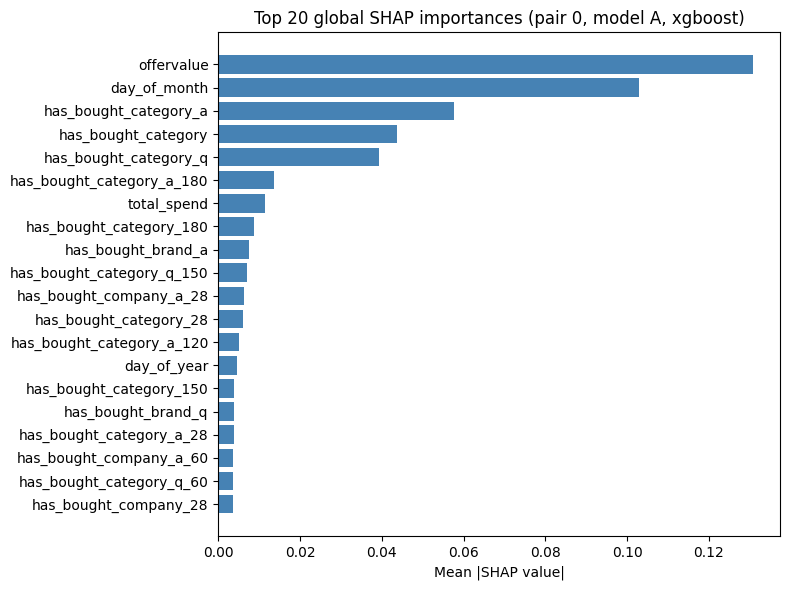

In [9]:
if MODEL_TYPE in ('xgboost', 'mlp_plr'):
    import matplotlib.pyplot as plt

    shap_A_0 = np.load(SHAP_DIR / 'pair_00' / 'shap_A.npy')   # (R, |F|, p)

    # Replica-averaged SHAP for pair 0
    phi_bar_A = shap_A_0.mean(axis=0)   # (|F|, p)

    # Global importance: mean |φ| per feature
    global_imp = np.abs(phi_bar_A).mean(axis=0)
    top_k = 20
    top_idx = np.argsort(global_imp)[::-1][:top_k]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        global_imp[top_idx[::-1]],
        color='steelblue'
    )
    ax.set_title(f'Top {top_k} global SHAP importances (pair 0, model A, {MODEL_TYPE})')
    ax.set_xlabel('Mean |SHAP value|')
    plt.tight_layout()
    plt.savefig(SHAP_DIR / 'global_importance_pair00_A.png', dpi=120)
    plt.show()
